In [18]:
import pickle
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Importamos los Datos

In [19]:
# Abre el archivo en modo lectura binaria ('rb')
with open('../data/bank_26.pkl', 'rb') as archivo:
    df = pickle.load(archivo)

/tmp/ipykernel_81249/3242033964.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(archivo)


# Preprocesado

## Feature Engineering

### Pdays
Para empezar con el preprocesado, primero vamos a hacer un poco de feature engineering con la variable pdays:

Vamos a crear un nuevo atributo **wasContacted** que valga 0 si el contacto es desconcocido y 1 en caso contrario.

Además, vamos a aplicar una categorización sobre pdays de manera que vamos a obtener un nuevo atributo ordinal **pdaysTransformed** que va a valer:
+ 0 si el contacto fue desconocido
+ 1 si el contacto fue inferior a 100 días
+ 2 si el contacto fue inferior a 200 días
+ 3 si el contacto fue inferior a 400 días
+ 4 si el contacto fue superior a 400 días

Otra transformación que se podría hacer sobre esta variable es crear un nuevo atributo donde los valores -1 se sustituyen por el máximo valor conocido de pdays.

In [20]:
# Pdays preprocessing
def pdays_transform(x):
    if x == -1:
        return 0
    elif x < 100:
        return 1
    elif x < 200:
        return 2
    elif x < 400:
        return 3
    else:
        return 4

# Función para el preprocesado de los pdays
def process_pdays(X):
    X_out = X.copy()
    X_out['wasContacted'] = X_out['pdays'].map(lambda x: 0 if x == -1 else 1)
    X_out['pdaysTransformed'] = X_out['pdays'].map(pdays_transform)
    return X_out

# Lo convertimos en un transformer para añadirlo al pipeline más adelante
pdays_transformer = FunctionTransformer(process_pdays)

## Missing Values

### Marital

Otras de las cuestiones que debemos resolver son los **Missing Values** asociados a **Marital**.

Recapitulando con lo que hemos visto en la EDA, esta variable categórica puede tener 3 valores:
+ Married
+ Divorced
+ Single

En principio resulta difícil imputar un valor a los que faltan usando otro atributo que nos pueda proporcionar pistas. Al mismo tiempo sería contraproducente eliminar la columna entera ya que contiene información que puede ser útil (recordar que los casados tendían más a no contratar depósitos a sí hacerlo).

De este modo, una primera aproximación puede ser completar estos valores faltantes con una nueva categoría 'unknown'

In [21]:
def process_marital(X):
    X_out = X.copy()
    X_out['marital'] = X_out['marital'].fillna('unknown')
    return X_out

marital_transformer = FunctionTransformer(process_marital)

## Eliminación de variables
Una parte del preprocesado y feature engineering es la eliminación de variables que no ayudan al modelo o que pueden producir data leakage. En este caso, eliminamos la variable pdays (la antigua) ya que ha sido preprocesada y transformada (en pdaysTransformed y wasContacted).

In [22]:
def drop_columns(X):
    return X.drop(['pdays'], axis=1, errors='ignore') 

drop_transformer = FunctionTransformer(drop_columns)

Una vez realizado el preprocesado y el feature engineering, procedemos al encoding y escalado final. Dividimos el set entre columnas numéricas y categóricas. A las numéricas le aplicamos un escalado estándar, y a las categóricas aplicamos un simple imputer (para eliminar valores nulos en caso de que los siga habiendo), y un OneHotEncoder para transformar en variables binarias las categóricas.

In [23]:
# Final encoder
def build_encoder(scaler: str) -> ColumnTransformer:
    num_cols = ['age', 'balance', 'day', 'campaign', 'pdaysTransformed', 'previous', 'wasContacted', 'duration']
    cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

    if scaler == "MinMax":
        num_transformer = Pipeline(steps=[
        ('scaler', MinMaxScaler())
        ])
    elif scaler == "Standard":
        num_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
        ])
    elif scaler == "Robust":
        num_transformer = Pipeline(steps=[
        ('scaler', RobustScaler())
        ])
    else:
        raise ValueError(f"El scaler {scaler} no se reconoce como uno válido\nScalers Aceptados: MinMax, Standard y Robust")
    

    # Transformer para variables categóricas (Imputación + Encoding)
    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary')) 
    ])

    # Unimos ambos transformers en un ColumnTransformer
    final_encoder = ColumnTransformer(
        transformers=[
            ('num', num_transformer, num_cols),
            ('cat', cat_transformer, cat_cols)
        ])
    
    return final_encoder

Separamos el set de datos entre datos de train y datos de test

In [24]:
# Separamos X e y
X = df.drop('deposit', axis=1)
y = df['deposit'].map({'yes': 1, 'no': 0})

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42, stratify=y)

## Elección del mejor Scaler

A continuación, vamos a entrenar modelos básicos de KNN aumentando el número de vecinos cada vez y usando diferentes escaladores numéricos para seleccionar aquel que funcione mejor para el resto de la práctica.

TODO: Redactar esto: Primero probamos con Acc pero quitando para los valores inferiores a 5 no estaba muy claro pero con f1 para las k´s mayores que coincide con mejores valores de f1 el mejor sin duda es RobustScaler.

In [25]:
scalers = ['MinMax', 'Standard', 'Robust'] # Scalers a probar
k_values = np.arange(1, 27, 2) # Dominio de vecinos (impares de 1 a 19)
results = [] # Lista con Acc obtenidos para cada elemento (scaler, k)

for scaler in scalers:
    for k in k_values:
        # Creamos el Pipeline concreto con el Scaler y el k correspondiente
        full_pipeline = Pipeline(steps=[
        ("pdays", pdays_transformer),     
        ("marital", marital_transformer),
        ("drop", drop_transformer),        
        ("encoder", build_encoder(scaler)),
        ("knn", KNeighborsClassifier(n_neighbors=k))
        ])

        # Entrenamos con Cross Validation y guardamos los resultados de esta tupla
        scores = cross_val_score(full_pipeline, X_train, y_train, cv=5, scoring='f1')

        # Guardamos los resultados de esta combinación (scaler, k) en la lista
        results.append(
            {
                'scaler': scaler,
                'n_neighbours': k,
                'metric': scores.mean()
            }
        )

# Convertimos los resultados en un pd.Dataframe para visualizarlo
results_df = pd.DataFrame(results)

Text(0, 0.5, 'F1-Score')

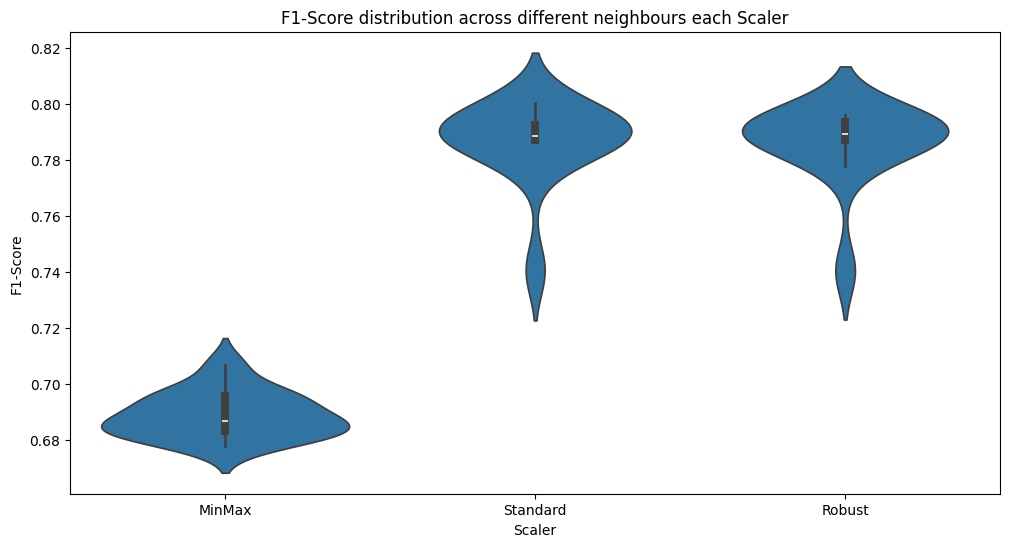

In [26]:
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=results_df,
    x='scaler',
    y='metric'
)
plt.title("F1-Score distribution across different neighbours each Scaler")
plt.xlabel("Scaler")
plt.ylabel("F1-Score")

Generamos el Pipeline de preprocesado con el Scaler final (que luego será incluido en el pipeline final, con el modelo incluido). Hemos diseñado esta arquitectura con tantos Pipelines ya que es la forma más modular para trabajar. Si quisiésemos añadir una función de preprocesado nueva, tan solo habría que escribir la función y meterla en el Pipeline, sin estar preocupados de si hay data leakage, de en que parte del código se realiza...

In [27]:
preprocessing = Pipeline(steps=[
    ("pdays", pdays_transformer),            # Arreglamos los -1 creando una variable dummy y una ordinal
    ("marital", marital_transformer),         # Rellenamos los valores nan de marital con 'unknown'
    ("drop", drop_transformer),              # Dropeamos columnas problemáticas (duration)
    ("encoder", build_encoder('Robust'))     # Imputamos nulos, codificamos texto y escalamos números
])

# Entrenamiento

## Entrenamiento Naive
Vamos a empezar a trabajar en esta fase entrenando un KNN y un DecisionTree de manera Naive, es decir, sin optimizar hiperparámetros.

Los modelos que obtengamos en este apartado nos servirán como benchmark de aquí en adelante.

También, vamos a medir sus tiempos de entrenamiento, por este motivo usaremos la función de skearln `cross_validate` que internamente calcula los tiempos además de otras métricas.

In [28]:
'''
Como de aquí en adelante se van a crear múltiples pipelines de entrenamiento
vamos a usar esta función para solo tener que especificar el modelo que usamos

Los parámetros aceptados para model son:
+ Dummy
+ KNN
+ Tree

Si no se especifica ningún modelo por defecto la función toma el valor KNN
'''
def create_train_pipeline(model: str="KNN") -> Pipeline:
    if model == "Dummy":
        return Pipeline(steps=[
        ("preprocessing", preprocessing),
        ("clf", DummyClassifier(strategy="most_frequent", random_state= 0))])
    elif model == "KNN":
        return Pipeline(steps=[
        ("preprocessing", preprocessing),
        ("clf", KNeighborsClassifier())])
    elif model == "Tree":
        return Pipeline(steps=[
        ("preprocessing", preprocessing),
        ("clf", DecisionTreeClassifier())])
    else:
        raise ValueError(f"El modelo {model} es deconocido.\nPrueba con KNN o Tree")

### DummyClassifier

En primer lugar, vamos a obtener el modelo que de aquí en adelante servirá como Benchmark.

Este modelo consistirá en un clasificador Dummy cuya estrategia es predecir constantemente la clase más fruecuente, es decir, en nuestro caso predice todo el rato que no se contrata un depósito.

Este Benchmark es crucial porque si hipotéticamente los modelos que usemos más adelante no mejoraran este resultado, quiere decir que no están aportando valor respecto a la predicción trivial de la clase mayoritaria.

Las métricas obtenidas son las siguientes:

+ **f1**: 0

+ **recall**: 0

+ **accuracy**: 0.525


Fijémonos en que la predicción trivial es nunca decir que hay un positivo, es decir, que nadie contrata un depósito. Al no haber positivos no hay ni verdaderos ni falsos positivos por lo que recall es 0 y por tanto f1 también.

In [29]:
# Creamos un nuevo Pipeline que usa el preprocesado anterior y un DummyClassifier
benchmark_model = create_train_pipeline("Dummy")

# Entrenamos el modelo usando Cross Validation sin optimización de hiperparámetros
results = cross_validate(benchmark_model, X_train, y_train, cv=5, scoring=['f1', 'recall','accuracy'], return_train_score=True)

# Imprimimos por pantalla las métricas de interés
for key, value in results.items():
    print(f"{key}: {round(value.mean(), 3)}")

fit_time: 0.022
score_time: 0.01
test_f1: 0.0
train_f1: 0.0
test_recall: 0.0
train_recall: 0.0
test_accuracy: 0.525
train_accuracy: 0.525


### KNN

En primer lugar, las métricas que nos servirán para comparar respecto al benchmark y los modelos con hiperparámetros optimizados son son las siguientes:

+ **f1**: 0.65

+ **recall**: 0.606

+ **accuracy**: 0.69

Cabe señalar que usamos como referencia las métricas del conjunto de test del algoritmo que son las que realmente nos importan porque son las obtenidas tras enseñarle al modelo el fold que no ha visto durante su entrenamiento (como en este caso dividimos el dataset en 5 folds en total obtenemos 5 métricas que nosotros comprimimos usando la media)

Por último, en media cada combinación ha tardado 0.029 s en entrenarse en el portátil de uno de los miembros del grupo.

In [30]:
# Creamos un nuevo Pipeline que usa el preprocesado anterior y un KNN
naive_pipe_knn = create_train_pipeline("KNN")

# Entrenamos el modelo usando Cross Validation sin optimización de hiperparámetros
results = cross_validate(naive_pipe_knn, X_train, y_train, cv=5, scoring=['f1', 'recall','accuracy'], return_train_score=True)

# Imprimimos por pantalla las métricas de interés
for key, value in results.items():
    print(f"{key}: {round(value.mean(), 3)}")

fit_time: 0.022
score_time: 0.102
test_f1: 0.785
train_f1: 0.856
test_recall: 0.757
train_recall: 0.836
test_accuracy: 0.803
train_accuracy: 0.866


### DecisionTree

En primer lugar, las métricas que nos servirán para comparar respecto al benchmark y los modelos con hiperparámetros optimizados son:

+ **f1**: 0.63

+ **recall**: 0.631

+ **accuracy**: 0.649

Por último, en media cada combinación ha tardado 0.145 s en entrenarse en el portátil de uno de los miembros del grupo.

In [31]:
# Creamos un nuevo Pipeline que usa el preprocesado anterior y un DecisionTree
naive_dec_tree = create_train_pipeline("Tree")

# Entrenamos el modelo usando Cross Validation sin optimización de hiperparámetros
results = cross_validate(naive_dec_tree, X_train, y_train, cv=5, scoring=['f1', 'recall','accuracy'], return_train_score=True)

# Imprimimos por pantalla las métricas de interés
for key, value in results.items():
    print(f"{key}: {round(value.mean(), 3)}")


fit_time: 0.12
score_time: 0.011
test_f1: 0.77
train_f1: 1.0
test_recall: 0.766
train_recall: 1.0
test_accuracy: 0.783
train_accuracy: 1.0


## Entrenamiento con HPO

Ahora que ya tenemos un Benchmark y diversos modelos naive con los que comparar podemos pasar a la optimización de hiperparámetros para intentar mejorar el rendimiento de nuestros modelos.

### KNN

Tras realizar la optimización de hiperparámetros:

El mejor modelo obtiene en el conjunto de test del CV: **f1** = 0.8119

Además, los hiperparámetros elegidos por la optimización en grid son:

+ **n_neighbors**: 16

+ **weights**: distance

+ **p** (metric): cosine

In [32]:
# Creamos un nuevo Pipeline que usa el preprocesado anterior y un KNN
hpo_pipe_knn = create_train_pipeline("KNN")

# Creamos un espacio de hiperparmámetros a optimizar
knn_param_grid = {
    "clf__n_neighbors": [3, 5, 7, 13, 15, 16, 17, 18, 19], # Vecinos para tomar la decisión
    "clf__weights": ["uniform", "distance"], # Los puntos más cercanos ponderan más o no
    'clf__metric': ['manhattan', 'euclidean', 'cosine'], # Probamos con diferentes métricas
}

# Instanciamos nuestro GridSearchCV
knn_grid = GridSearchCV(
    hpo_pipe_knn, 
    param_grid=knn_param_grid, 
    cv=5, 
    scoring="f1", 
    return_train_score=True)

# Entrenamos el modelo
knn_grid.fit(X_train, y_train)

# Imprimimos los hiperparámetros del mejor modelo obtenido
print(f"Best Score (F1): {knn_grid.best_score_}\nBest Model: {knn_grid.best_params_}")

Best Score (F1): 0.811899375129636
Best Model: {'clf__metric': 'cosine', 'clf__n_neighbors': 16, 'clf__weights': 'distance'}


Como se puede observar con la salida al hacer cross validation (después de hacer varias iteraciones e ir probando valores extremos), hemos obtenido la mejor configuración para KNN, que sería:

+ **n_neighbors**: 16

+ **weights**: distance

+ **p**: cosine

Sin embargo queremos probar y graficar diversos parámetros (principalmente **n_neighbours**) dejando el resto de parámetros con sus mejores valores.

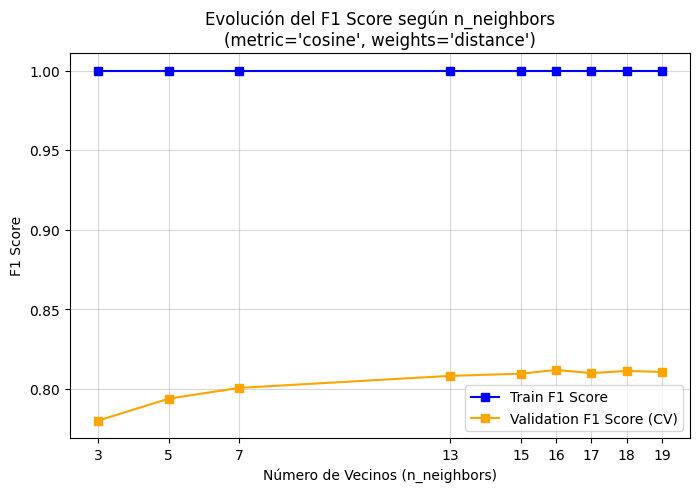

In [33]:
# Convertimos el diccionario de resultados a un DataFrame para manejarlo fácilmente
resultados_df = pd.DataFrame(knn_grid.cv_results_)

# Obtenemos los mejores parámetros fijos detectados
mejor_metrica = knn_grid.best_params_['clf__metric']
mejores_pesos = knn_grid.best_params_['clf__weights']

# Filtramos los datos ceteris paribus (dejando fijo metric y weights)
datos_filtrados = resultados_df[
    (resultados_df['param_clf__metric'] == mejor_metrica) & 
    (resultados_df['param_clf__weights'] == mejores_pesos)
].copy()

# Ordenamos por n_neighbors de menor a mayor para que la línea de la gráfica se trace bien
datos_filtrados = datos_filtrados.sort_values(by='param_clf__n_neighbors')

# Extraemos los datos para los ejes
eje_x = datos_filtrados['param_clf__n_neighbors']
eje_y_test = datos_filtrados['mean_test_score']
eje_y_train = datos_filtrados['mean_train_score']

# Creamos la gráfica
plt.figure(figsize=(8, 5))

plt.plot(eje_x, eje_y_train, marker='s', linestyle='-', color='blue', label='Train F1 Score')

# Graficamos los datos de Validación/Test (los realmente importantes)
plt.plot(eje_x, eje_y_test, marker='s', linestyle='-', color='orange', label='Validation F1 Score (CV)')

# Detalles estéticos
plt.title(f"Evolución del F1 Score según n_neighbors\n(metric='{mejor_metrica}', weights='{mejores_pesos}')")
plt.xlabel("Número de Vecinos (n_neighbors)")
plt.ylabel("F1 Score")
plt.xticks(eje_x) # Para que solo salgan los números exactos que probaste en el eje X
plt.legend()
plt.grid(True, alpha=0.5)

# Mostrar la gráfica
plt.show()

### DecisionTree

Tras realizar la optimización de hiperparámetros:

El mejor modelo obtiene en el conjunto de test del CV: **f1** = 0.8294

Además, los hiperparámetros elegidos por la optimización en grid son:

+ **criterion**: gini

+ **max_depth**: 13

+ **min_samples_split**: 2

+ **min_samples_leaf**: 3

+ **min_impurity_decrease**: 1e-3

In [34]:
# Creamos un nuevo Pipeline que usa el preprocesado anterior y un KNN
hpo_pipe_tree = create_train_pipeline("Tree")

# Creamos un espacio de hiperparmámetros a optimizar
# Creamos un espacio de hiperparmámetros a optimizar
tree_param_grid = {
    "clf__criterion": ['gini', 'entropy', 'log_loss'],
    "clf__max_depth": [10, 12, 13, 14, 15], 
    "clf__min_samples_split": [2, 4, 6], 
    "clf__min_samples_leaf": [3, 5, 7], 
    "clf__min_impurity_decrease": [1e-4, 1e-3, 1e-2] 
}

# Instanciamos nuestro GridSearchCV
tree_grid = GridSearchCV(
    hpo_pipe_tree, 
    param_grid=tree_param_grid, 
    cv=5, 
    scoring="f1", 
    return_train_score=True)

# Entrenamos el modelo
tree_grid.fit(X_train, y_train)

# Imprimimos los hiperparámetros del mejor modelo obtenido
print(f"Best Score: {tree_grid.best_score_}\nBest Model: {tree_grid.best_params_}")

Best Score: 0.8294571900792806
Best Model: {'clf__criterion': 'gini', 'clf__max_depth': 13, 'clf__min_impurity_decrease': 0.001, 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 2}


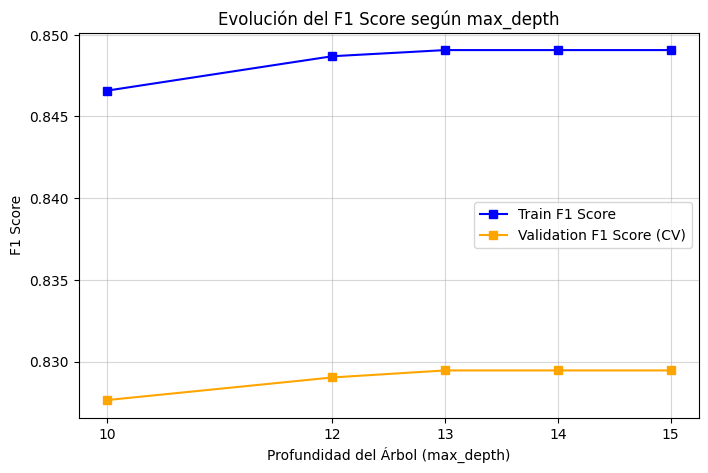

In [35]:
# Convertimos el diccionario de resultados a un DataFrame
resultados_tree_df = pd.DataFrame(tree_grid.cv_results_)

# Mejores parámetros fijos
mejor_crit = tree_grid.best_params_['clf__criterion']
mejor_split = tree_grid.best_params_['clf__min_samples_split']
mejor_leaf = tree_grid.best_params_['clf__min_samples_leaf']
mejor_imp = tree_grid.best_params_['clf__min_impurity_decrease']

# Filtramos ceteris paribus (solo variamos max_depth)
datos_filtrados_tree = resultados_tree_df[
    (resultados_tree_df['param_clf__criterion'] == mejor_crit) & 
    (resultados_tree_df['param_clf__min_samples_split'] == mejor_split) &
    (resultados_tree_df['param_clf__min_samples_leaf'] == mejor_leaf) &
    (resultados_tree_df['param_clf__min_impurity_decrease'] == mejor_imp)
].copy()

datos_filtrados_tree = datos_filtrados_tree.sort_values(by='param_clf__max_depth')

eje_x_tree = datos_filtrados_tree['param_clf__max_depth']
eje_y_test_tree = datos_filtrados_tree['mean_test_score']
eje_y_train_tree = datos_filtrados_tree['mean_train_score']

plt.figure(figsize=(8, 5))
plt.plot(eje_x_tree, eje_y_train_tree, marker='s', linestyle='-', color='blue', label='Train F1 Score')
plt.plot(eje_x_tree, eje_y_test_tree, marker='s', linestyle='-', color='orange', label='Validation F1 Score (CV)')

plt.title("Evolución del F1 Score según max_depth")
plt.xlabel("Profundidad del Árbol (max_depth)")
plt.ylabel("F1 Score")
plt.xticks(eje_x_tree)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()


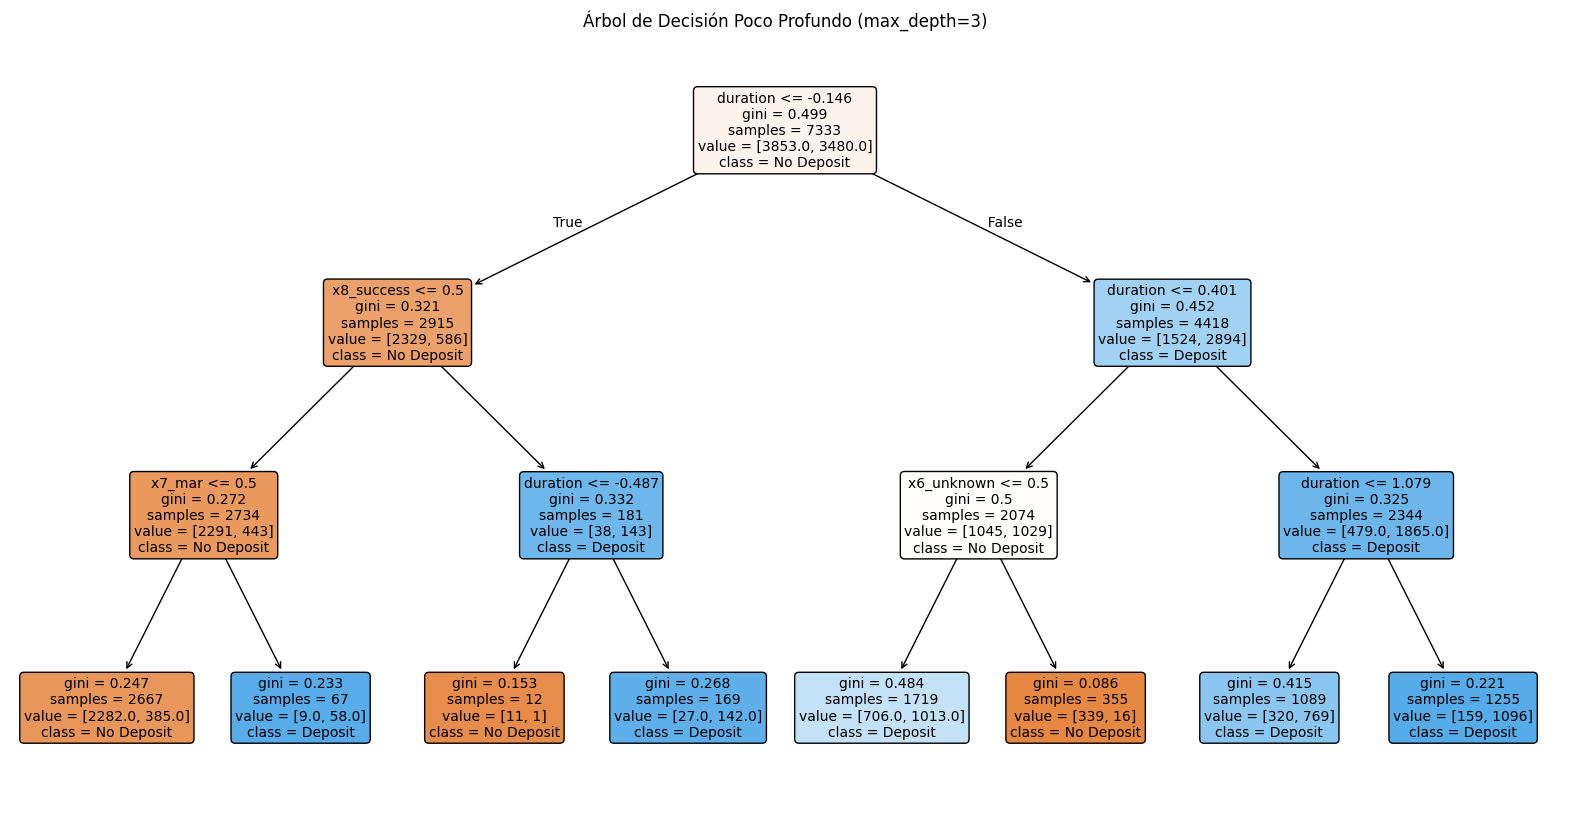

In [ ]:
from sklearn.tree import plot_tree

# Entrenamos un árbol poco profundo
shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
shallow_pipe = Pipeline(steps=[
    ("preprocessing", preprocessing),
    ("clf", shallow_tree)
])

shallow_pipe.fit(X_train, y_train)

# Nombres de las características generados por OneHotEncoder y columnas numéricas
preprocessor = shallow_pipe.named_steps['preprocessing']
column_transformer = preprocessor.named_steps['encoder']
cat_features = column_transformer.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out()
num_features = ['age', 'balance', 'day', 'campaign', 'pdaysTransformed', 'previous', 'wasContacted', 'duration']
feature_names = list(num_features) + list(cat_features)

plt.figure(figsize=(20, 10))
plot_tree(shallow_tree, feature_names=feature_names, class_names=['No Deposit', 'Deposit'], filled=True, rounded=True, fontsize=10)
plt.title("Árbol de Decisión Poco Profundo")
plt.show()


### Interpretación del Árbol de Decisión (max_depth=3)

Al limitar la profundidad del árbol a 3, podemos observar claramente cuáles son las reglas principales que el modelo usa para decidir si un cliente contratará o no el depósito. (Nota: los valores numéricos como `duration` aparecen transformados porque se les ha aplicado el `RobustScaler`).

1. **La variable más crítica es la duración de la llamada (`duration`)**:
   - **Nodo Raíz**: El primer corte que hace el modelo es evaluar si la duración es `<= -0.146`. 
   - **Llamadas largas (Rama Derecha)**: Si la llamada dura más de ese umbral (False), el cliente tiene una altísima probabilidad de contratar el depósito (la clase mayoritaria en esos nodos empieza a ser `Deposit`). Si además la duración supera el `0.401`, la probabilidad de éxito se dispara.
   - **Llamadas cortas (Rama Izquierda)**: Si la llamada ha sido muy corta (True), la tendencia general es que el cliente termine rechazando el depósito (`No Deposit`).

2. **El éxito de la campaña anterior (`x8_success`) salva las llamadas cortas**:
   - Si seguimos la rama izquierda (llamadas cortas), el siguiente nodo evalúa `x8_success <= 0.5` (es decir, si la campaña de marketing anterior **no** fue un éxito).
   - Si el cliente ya había contratado en el pasado (False), a pesar de que la llamada actual haya sido corta, sigue habiendo una gran probabilidad de que contrate el depósito (143 positivos frente a 38 negativos).
   
3. **Otras variables de apoyo**:
   - **Mes de Marzo (`x7_mar`) y Contacto Desconocido (`x6_unknown`)**: En las hojas más profundas, el árbol usa otras características categóricas (como si el contacto fue en el mes de marzo o si el método de contacto es desconocido) para refinar pequeñas impurezas en los grupos, aunque su peso es mucho menor que el de la duración.

**Conclusión visual**: 
El modelo nos indica de forma muy intuitiva que **cuanto más tiempo se logre mantener al cliente al teléfono, muchas más opciones hay de que contrate el depósito**. Sin embargo, si el cliente ya ha confiado en nosotros en campañas previas (poutcome = success), tomará la decisión afirmativa muy rápido.


## Conclusiones: KNN vs Decision Trees
1. **¿Cuál es el mejor método?**: Observando los resultados, el Árbol de Decisión con HPO supera ligeramente al KNN con HPO en F1-Score (aprox ~0.83 vs ~0.81). Por tanto, Tree es el mejor método en términos predictivos.

2. **¿A qué coste computacional?**: Los modelos basados en árboles tuvieron tiempos de entrenamiento ligeramente más altos que KNN en su versión Naive, pero en HPO KNN sufre mucho más debido al elevado cálculo de distancias.

3. **¿Los resultados son mejores que los modelos triviales/naive/dummy?**: Sí. El DummyClassifier obtuvo F1=0, mientras que tanto KNN como Trees logran F1-Scores superiores a 0.81.

4. **¿El ajuste mejora los valores por omisión?**: Sí, la optimización (HPO) mejoró significativamente las métricas en ambos casos al evitar el sobreajuste y encontrar los mejores vecinos / balance adecuado de profundidad.
